# Circular Trips Detection

This notebook detects trips that start from a specific cell, move through a sequence of cells, and return to the starting cell. It analyzes movement patterns in cellular networks to identify complete round-trip journeys.

## 1. Import Required Libraries and Setup DuckDB

Import necessary libraries for data manipulation, visualization, and DuckDB connectivity.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from collections import deque, defaultdict
from datetime import datetime, timedelta
import seaborn as sns
from typing import List, Tuple, Dict, Set
import warnings
import duckdb

warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Define the Trip Class

Create a Trip class to represent individual trips with properties and validation methods.

## 1.5 Setup DuckDB Connection

Configure DuckDB to read trip data from parquet files generated by the trip extraction pipeline.

In [5]:
# DuckDB configuration
DB_PATH = "/home/jovyan/data/analytics.duckdb"
TRIPS_STAGE_DIR = "/home/jovyan/data/stage/trips"

# Connect to DuckDB
con = duckdb.connect(DB_PATH)
con.execute(f"SET memory_limit='4GB'")
con.execute("SET preserve_insertion_order=false")
con.execute("SET threads=4")

print(f"Connected to DuckDB at {DB_PATH}")
print(f"Trips parquet location: {TRIPS_STAGE_DIR}")

Connected to DuckDB at /home/jovyan/data/analytics.duckdb
Trips parquet location: /home/jovyan/data/stage/trips


In [6]:
class Trip:
    """Represents a trip through a sequence of cells."""
    
    def __init__(self, trip_id: str, user_id: str, start_cell: str, 
                 visited_cells: List[str], timestamps: List[datetime]):
        """
        Initialize a Trip.
        
        Parameters:
        -----------
        trip_id : str
            Unique identifier for the trip
        user_id : str
            Identifier of the entity making the trip
        start_cell : str
            Starting cell of the trip
        visited_cells : List[str]
            List of cells visited in order (including start and end)
        timestamps : List[datetime]
            Timestamps corresponding to each cell visit
        """
        self.trip_id = trip_id
        self.user_id = user_id
        self.start_cell = start_cell
        self.visited_cells = visited_cells
        self.timestamps = timestamps
        self.end_cell = visited_cells[-1] if visited_cells else None
        
    def is_complete_trip(self) -> bool:
        """Check if the trip returns to the starting cell."""
        return len(self.visited_cells) > 1 and self.start_cell == self.end_cell
    
    def is_valid_trip(self) -> bool:
        """Check if the trip visits at least 2 unique cells."""
        return len(self.get_unique_cells()) >= 2
    
    def get_path(self) -> str:
        """Get the path as a string representation."""
        return ' -> '.join(self.visited_cells)
    
    def get_unique_cells(self) -> Set[str]:
        """Get the set of unique cells visited."""
        return set(self.visited_cells)
    
    def get_trip_duration(self) -> timedelta:
        """Calculate the total duration of the trip."""
        if len(self.timestamps) > 1:
            return self.timestamps[-1] - self.timestamps[0]
        return timedelta(0)
    
    def get_hop_count(self) -> int:
        """Get the number of hops (transitions between cells)."""
        return len(self.visited_cells) - 1 if self.visited_cells else 0
    
    def __repr__(self):
        return (f"Trip(id={self.trip_id}, user={self.user_id}, "
                f"path={self.get_path()}, complete={self.is_complete_trip()})")


class TripDetector:
    """Detects circular trips in movement data."""
    
    def __init__(self):
        self.trips: List[Trip] = []
        self.complete_trips: List[Trip] = []
        
    def detect_trips(self, movements_df: pd.DataFrame, 
                     session_timeout_minutes: int = 60) -> List[Trip]:
        """
        Detect trips from movement data.
        
        Parameters:
        -----------
        movements_df : pd.DataFrame
            DataFrame with columns: ['user_id', 'cell', 'timestamp']
        session_timeout_minutes : int
            Time gap that marks the end of a trip
            
        Returns:
        --------
        List[Trip]
            List of detected Trip objects
        """
        self.trips = []
        movements_df = movements_df.sort_values(['user_id', 'timestamp']).reset_index(drop=True)
        
        for user_id in movements_df['user_id'].unique():
            user_movements = movements_df[movements_df['user_id'] == user_id].reset_index(drop=True)
            
            current_trip_cells = [user_movements.iloc[0]['cell']]
            current_trip_times = [user_movements.iloc[0]['timestamp']]
            start_cell = user_movements.iloc[0]['cell']
            
            for i in range(1, len(user_movements)):
                prev_time = user_movements.iloc[i-1]['timestamp']
                curr_time = user_movements.iloc[i]['timestamp']
                curr_cell = user_movements.iloc[i]['cell']
                
                time_gap = (curr_time - prev_time).total_seconds() / 60
                
                # Check if this is continuation of the same trip or a new trip
                if time_gap <= session_timeout_minutes:
                    current_trip_cells.append(curr_cell)
                    current_trip_times.append(curr_time)
                else:
                    # End current trip and start a new one
                    if len(current_trip_cells) > 1:
                        trip = Trip(
                            trip_id=f"{user_id}_{len(self.trips)}",
                            user_id=user_id,
                            start_cell=start_cell,
                            visited_cells=current_trip_cells,
                            timestamps=current_trip_times
                        )
                        self.trips.append(trip)
                    
                    # Start new trip
                    start_cell = curr_cell
                    current_trip_cells = [curr_cell]
                    current_trip_times = [curr_time]
            
            # Add the last trip
            if len(current_trip_cells) > 1:
                trip = Trip(
                    trip_id=f"{user_id}_{len(self.trips)}",
                    user_id=user_id,
                    start_cell=start_cell,
                    visited_cells=current_trip_cells,
                    timestamps=current_trip_times
                )
                self.trips.append(trip)
        
        return self.trips
    
    def filter_complete_trips(self) -> List[Trip]:
        """Filter trips that return to their starting cell and visit at least 2 unique cells."""
        self.complete_trips = [trip for trip in self.trips 
                               if trip.is_complete_trip() and trip.is_valid_trip()]
        return self.complete_trips
    
    def get_statistics(self) -> Dict:
        """Get statistics about detected trips."""
        if not self.trips:
            return {}
        
        complete = len(self.complete_trips)
        total = len(self.trips)
        
        hop_counts = [trip.get_hop_count() for trip in self.complete_trips]
        durations = [trip.get_trip_duration().total_seconds() / 3600 
                    for trip in self.complete_trips]  # in hours
        
        return {
            'total_trips': total,
            'complete_trips': complete,
            'complete_percentage': (complete / total * 100) if total > 0 else 0,
            'avg_hops_per_complete_trip': np.mean(hop_counts) if hop_counts else 0,
            'max_hops_per_trip': max(hop_counts) if hop_counts else 0,
            'avg_duration_hours': np.mean(durations) if durations else 0,
        }

## 3. Create Sample Cell Grid Data

Generate realistic sample data representing movement patterns through a cell network.

## 3.5 Helper Functions for Cell Sequence Parsing

Functions to parse and convert cell sequence strings from DuckDB into movement records.

In [30]:
def parse_cell_sequence(cell_sequence: str) -> List[str]:
    """
    Parse cell sequence string (e.g., 'Cell_0_0 -> Cell_1_0 -> Cell_1_1')
    into a list of cell IDs.
    
    Parameters:
    -----------
    cell_sequence : str
        Cell sequence as a string with ' -> ' separators
        
    Returns:
    --------
    List[str]
        List of cell IDs
    """
    if not cell_sequence or pd.isna(cell_sequence):
        return []
    return [cell.strip() for cell in cell_sequence.split(' -> ')]


def load_trips_from_duckdb(limit: int = None, 
                            min_handovers: int = 2,
                            min_cells: int = 2,
                            max_duration_minutes: int = 360) -> pd.DataFrame:
    """
    Load trips from DuckDB parquet files.
    
    Parameters:
    -----------
    limit : int, optional
        Maximum number of trips to load
    min_handovers : int
        Minimum handovers to include
    min_cells : int
        Minimum unique cells to include
    max_duration_minutes : int
        Maximum trip duration in minutes (default 360 = 6 hours)
        
    Returns:
    --------
    pd.DataFrame
        DataFrame with columns: ['vehicle_id', 'trip_id', 'trip_start', 
                                'trip_end', 'duration_minutes', 'n_cells', 
                                'n_handovers', 'cell_sequence']
    """
    try:
        # Load trips table from parquet
        con.execute("DROP TABLE IF EXISTS trips_duckdb")
        con.execute(f"""
            CREATE TABLE trips_duckdb AS
            SELECT * FROM read_parquet('{TRIPS_STAGE_DIR}/**/*.parquet')
        """)
        
        query = f"""
        SELECT 
            vehicle_id, 
            trip_id, 
            trip_start, 
            trip_end, 
            duration_minutes, 
            n_cells, 
            n_handovers, 
            cell_sequence
        FROM trips_duckdb
        WHERE n_handovers >= {min_handovers}
          AND n_cells >= {min_cells}
          AND duration_minutes <= {max_duration_minutes}
          AND cell_sequence IS NOT NULL
        ORDER BY trip_start
        """
        
        if limit:
            query += f" LIMIT {limit}"
        
        df = con.execute(query).df()
        print(f"Loaded {len(df)} trips from DuckDB")
        return df
        
    except Exception as e:
        print(f"Error loading from DuckDB: {e}")
        print("Falling back to sample data generation...")
        return None


# Test connection
try:
    summary = con.execute(f"""
        SELECT COUNT(*) as total_files
        FROM glob('{TRIPS_STAGE_DIR}/**/*.parquet')
    """).fetchall()
    print(f"Found parquet files in {TRIPS_STAGE_DIR}")
except Exception as e:
    print(f"Note: DuckDB connection ready, but trips data may not be available yet: {e}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Found parquet files in /home/jovyan/data/stage/trips


In [ ]:
def generate_sample_movements(num_users: int = 10, 
                             num_records: int = 1000,
                             seed: int = 42) -> pd.DataFrame:
    """
    Generate sample movement data through a cell grid.
    
    Parameters:
    -----------
    num_users : int
        Number of users to simulate
    num_records : int
        Total number of movement records
    seed : int
        Random seed for reproducibility
        
    Returns:
    --------
    pd.DataFrame
        DataFrame with columns: ['user_id', 'cell', 'timestamp']
    """
    np.random.seed(seed)
    
    # Define a 5x5 grid of cells
    grid_size = 5
    cells = [f"Cell_{i}_{j}" for i in range(grid_size) for j in range(grid_size)]
    users = [f"User_{i}" for i in range(num_users)]
    
    # Create movement graph - adjacent cells are more likely
    cell_adjacency = defaultdict(list)
    for i in range(grid_size):
        for j in range(grid_size):
            current_cell = f"Cell_{i}_{j}"
            # Adjacent cells
            for di, dj in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                ni, nj = i + di, j + dj
                if 0 <= ni < grid_size and 0 <= nj < grid_size:
                    cell_adjacency[current_cell].append(f"Cell_{ni}_{nj}")
    
    # Generate movements
    records = []
    current_time = datetime(2024, 1, 1, 0, 0, 0)
    
    for _ in range(num_records):
        user = np.random.choice(users)
        
        if not records or records[-1]['user_id'] != user:
            # New user session
            current_cell = np.random.choice(cells)
        else:
            # Continue from previous cell or jump to adjacent
            prev_cell = records[-1]['cell']
            if np.random.random() < 0.7 and prev_cell in cell_adjacency:
                # Move to adjacent cell with higher probability
                current_cell = np.random.choice(cell_adjacency[prev_cell] + [prev_cell])
            else:
                # Random jump with lower probability
                current_cell = np.random.choice(cells)
        
        # Add random interval (5-15 minutes)
        time_delta = timedelta(minutes=np.random.randint(5, 15))
        current_time += time_delta
        
        records.append({
            'user_id': user,
            'cell': current_cell,
            'timestamp': current_time
        })
    
    return pd.DataFrame(records)


# Try to load real data from DuckDB, fall back to sample data
# Load all trips with max 6-hour duration filter
trips_df = load_trips_from_duckdb(max_duration_minutes=360)

if trips_df is None or len(trips_df) == 0:
    print("\n⚠️  Using generated sample data for demonstration")
    print("-" * 60)
    # Generate sample data instead
    movements_df = generate_sample_movements(num_users=15, num_records=2000)
    print(f"Generated {len(movements_df)} movement records")
    print(f"\nFirst few records:")
    print(movements_df.head(10))
else:
    print("\n✅ Using real DuckDB trip data")
    print("-" * 60)
    print(f"Loaded {len(trips_df)} real trips from DuckDB")
    print(f"\nFirst few trips:")
    print(trips_df[['vehicle_id', 'trip_id', 'duration_minutes', 'n_cells', 'n_handovers']].head(10))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Loaded 1000 trips from DuckDB

✅ Using real DuckDB trip data
------------------------------------------------------------
Loaded 1000 real trips from DuckDB

First few trips:
                         vehicle_id  \
0  F140A413CDBACB245F79DAE1D7438EC4   
1  F140A413CDBACB245F79DAE1D7438EC4   
2  F140A413CDBACB245F79DAE1D7438EC4   
3  F140A413CDBACB245F79DAE1D7438EC4   
4  F140A413CDBACB245F79DAE1D7438EC4   
5  F140A413CDBACB245F79DAE1D7438EC4   
6  F140A413CDBACB245F79DAE1D7438EC4   
7  F140A413CDBACB245F79DAE1D7438EC4   
8  F140A413CDBACB245F79DAE1D7438EC4   
9  F140A413CDBACB245F79DAE1D7438EC4   

                                     trip_id  duration_minutes  n_cells  \
0  F140A413CDBACB245F79DAE1D7438EC4_trip_012              48.4        3   
1  F140A413CDBACB245F79DAE1D7438EC4_trip_005              20.9        3   
2  F140A413CDBACB245F79DAE1D7438EC4_trip_009              24.2        3   
3  F140A413CDBACB245F79DAE1D7438EC4_trip_005              24.2        4   
4  F140A413CDBACB245

In [31]:
# Inspect the full dataset
print("=" * 80)
print("DATASET OVERVIEW".center(80))
print("=" * 80)

# Load all trips (no limit, 6 hour max duration)
full_trips_df = load_trips_from_duckdb(limit=None, max_duration_minutes=360)

if full_trips_df is not None and len(full_trips_df) > 0:
    print(f"\n📊 Total trips in dataset: {len(full_trips_df):,}")
    print(f"🚗 Unique vehicles: {full_trips_df['vehicle_id'].nunique():,}")
    print(f"📅 Date range: {full_trips_df['trip_start'].min()} to {full_trips_df['trip_start'].max()}")
    print(f"⏱️  Average trip duration: {full_trips_df['duration_minutes'].mean():.2f} minutes")
    print(f"🔀 Average handovers per trip: {full_trips_df['n_handovers'].mean():.2f}")
    print(f"📍 Average unique cells per trip: {full_trips_df['n_cells'].mean():.2f}")
    print("=" * 80)
else:
    print("No data loaded - no trips with max duration of 6 hours found")
    print("=" * 80)

                                DATASET OVERVIEW                                


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Loaded 12990754 trips from DuckDB

📊 Total trips in dataset: 12,990,754
🚗 Unique vehicles: 96,861
📅 Date range: 2025-01-01 18:47:51.185000 to 2025-11-01 23:51:38.481000
⏱️  Average trip duration: 36.60 minutes
🔀 Average handovers per trip: 5.42
📍 Average unique cells per trip: 4.68


## 4. Implement Trip Detection Algorithm

Execute the trip detection algorithm on movement data (either from DuckDB or generated sample data).

In [32]:
# Determine data source and convert to uniform format
if trips_df is not None and len(trips_df) > 0:
    # Parse DuckDB trips into movement records
    print("Converting DuckDB trip data to movement format...")
    movements_list = []
    
    for idx, row in trips_df.iterrows():
        cell_sequence = parse_cell_sequence(row['cell_sequence'])
        
        if len(cell_sequence) > 1:
            # Create synthetic timestamps across the trip duration
            trip_duration = pd.Timedelta(minutes=row['duration_minutes'])
            start_time = pd.Timestamp(row['trip_start'])
            
            # Distribute timestamps evenly across the trip
            for i, cell in enumerate(cell_sequence):
                progress = i / (len(cell_sequence) - 1) if len(cell_sequence) > 1 else 0
                timestamp = start_time + (trip_duration * progress)
                
                movements_list.append({
                    'user_id': row['vehicle_id'],
                    'cell': cell,
                    'timestamp': timestamp,
                    'trip_id': row['trip_id']
                })
    
    movements_df = pd.DataFrame(movements_list)
    print(f"Converted to {len(movements_df)} movement records from {len(trips_df)} trips")

# Initialize detector and detect trips
detector = TripDetector()
all_trips = detector.detect_trips(movements_df, session_timeout_minutes=15)

print(f"\nTotal trips detected: {len(all_trips)}")
print(f"\nSample trips:")
for i, trip in enumerate(all_trips[:5]):
    print(f"{i+1}. {trip}")
    print(f"   Path: {trip.get_path()}")
    print(f"   Duration: {trip.get_trip_duration()}")
    print(f"   Unique cells: {len(trip.get_unique_cells())}\n")

Converting DuckDB trip data to movement format...
Converted to 5687 movement records from 1000 trips

Total trips detected: 980

Sample trips:
1. Trip(id=01EC837476D754AA063CFBA426AB1732_0, user=01EC837476D754AA063CFBA426AB1732, path=69387237 -> 69387018 -> 69495268, complete=False)
   Path: 69387237 -> 69387018 -> 69495268
   Duration: 0 days 00:16:06
   Unique cells: 3

2. Trip(id=01EC837476D754AA063CFBA426AB1732_1, user=01EC837476D754AA063CFBA426AB1732, path=54929162 -> 69169417 -> 69255946 -> 69516297 -> 53883914 -> 54224648 -> 53845000 -> 54782729, complete=False)
   Path: 54929162 -> 69169417 -> 69255946 -> 69516297 -> 53883914 -> 54224648 -> 53845000 -> 54782729
   Duration: 0 days 00:56:24
   Unique cells: 8

3. Trip(id=01EC837476D754AA063CFBA426AB1732_2, user=01EC837476D754AA063CFBA426AB1732, path=70566116 -> 70565896 -> 70565897 -> 70567433 -> 70568970 -> 70569189, complete=False)
   Path: 70566116 -> 70565896 -> 70565897 -> 70567433 -> 70568970 -> 70569189
   Duration: 0 day

## 5. Filter and Validate Complete Trips

Filter detected trips to identify only those that form complete cycles (start and end at the same cell).

In [33]:
# Filter complete trips
complete_trips = detector.filter_complete_trips()

print(f"Complete trips (return to start): {len(complete_trips)}")
print(f"\nSample complete trips:")
for i, trip in enumerate(complete_trips[:5]):
    print(f"{i+1}. {trip}")
    print(f"   Path: {trip.get_path()}")
    print(f"   Hops: {trip.get_hop_count()}")
    print(f"   Duration: {trip.get_trip_duration()}\n")

# Get statistics
stats = detector.get_statistics()
print("Trip Statistics:")
print(f"  Total trips: {stats['total_trips']}")
print(f"  Complete trips: {stats['complete_trips']}")
print(f"  Complete percentage: {stats['complete_percentage']:.2f}%")
print(f"  Avg hops per complete trip: {stats['avg_hops_per_complete_trip']:.2f}")
print(f"  Max hops per trip: {stats['max_hops_per_trip']:.0f}")
print(f"  Avg duration (hours): {stats['avg_duration_hours']:.2f}")

Complete trips (return to start): 94

Sample complete trips:
1. Trip(id=16621DDA5F0E80D3B3045F101C0F59DB_65, user=16621DDA5F0E80D3B3045F101C0F59DB, path=88355082 -> 88355297 -> 88355082 -> 88355095 -> 88355082 -> 88355297 -> 88355096 -> 88355082, complete=True)
   Path: 88355082 -> 88355297 -> 88355082 -> 88355095 -> 88355082 -> 88355297 -> 88355096 -> 88355082
   Hops: 7
   Duration: 0 days 00:56:36

2. Trip(id=16621DDA5F0E80D3B3045F101C0F59DB_69, user=16621DDA5F0E80D3B3045F101C0F59DB, path=88355297 -> 88355095 -> 88355082 -> 88355297 -> 88355082 -> 88355297 -> 88355082 -> 88355297 -> 88355082 -> 88355095 -> 88355297, complete=True)
   Path: 88355297 -> 88355095 -> 88355082 -> 88355297 -> 88355082 -> 88355297 -> 88355082 -> 88355297 -> 88355082 -> 88355095 -> 88355297
   Hops: 10
   Duration: 0 days 01:20:48

3. Trip(id=16621DDA5F0E80D3B3045F101C0F59DB_72, user=16621DDA5F0E80D3B3045F101C0F59DB, path=88355297 -> 88355095 -> 88355082 -> 88355095 -> 88355297 -> 88355082 -> 88355095 -> 88

## 5.5 Trip Data Summary

Summary statistics of detected trips including vehicle counts, trip metrics, and activity analysis.


In [34]:
# Calculate trip data summary
print("=" * 80)
print("TRIP DATA SUMMARY".center(80))
print("=" * 80)

# Number of trips detected
num_trips_detected = len(all_trips)
print(f"\n📊 Number of Trips Detected: {num_trips_detected}")

# Number of vehicles detected
vehicles = movements_df['user_id'].unique()
num_vehicles = len(vehicles)
print(f"🚗 Number of Vehicles Detected: {num_vehicles}")

# Average trip time
trip_durations = [trip.get_trip_duration().total_seconds() / 60 for trip in all_trips]  # in minutes
avg_trip_duration_minutes = np.mean(trip_durations) if trip_durations else 0
avg_trip_duration_hours = avg_trip_duration_minutes / 60
print(f"⏱️  Average Trip Duration: {avg_trip_duration_hours:.2f} hours ({avg_trip_duration_minutes:.2f} minutes)")

# Most active vehicle (vehicle with most trips)
vehicle_trip_counts = movements_df['user_id'].value_counts()
most_active_vehicle = vehicle_trip_counts.idxmax()
most_active_vehicle_count = vehicle_trip_counts.max()
print(f"⭐ Most Active Vehicle: {most_active_vehicle} ({most_active_vehicle_count} records)")

# Additional statistics
print("\n" + "-" * 80)
print("ADDITIONAL STATISTICS")
print("-" * 80)
print(f"Average movements per vehicle: {movements_df.groupby('user_id').size().mean():.1f}")
print(f"Total movement records: {len(movements_df)}")
print(f"Complete (circular) trips: {len(complete_trips)} ({len(complete_trips)/num_trips_detected*100:.1f}%)")
print(f"Average hops per complete trip: {stats['avg_hops_per_complete_trip']:.2f}")
print("=" * 80)


                               TRIP DATA SUMMARY                                

📊 Number of Trips Detected: 980
🚗 Number of Vehicles Detected: 25
⏱️  Average Trip Duration: 0.65 hours (38.89 minutes)
⭐ Most Active Vehicle: 16621DDA5F0E80D3B3045F101C0F59DB (1043 records)

--------------------------------------------------------------------------------
ADDITIONAL STATISTICS
--------------------------------------------------------------------------------
Average movements per vehicle: 227.5
Total movement records: 5687
Complete (circular) trips: 94 (9.6%)
Average hops per complete trip: 5.38


## 6. Visualize Trip Paths

Create various visualizations to display detected trips and their patterns across the grid.

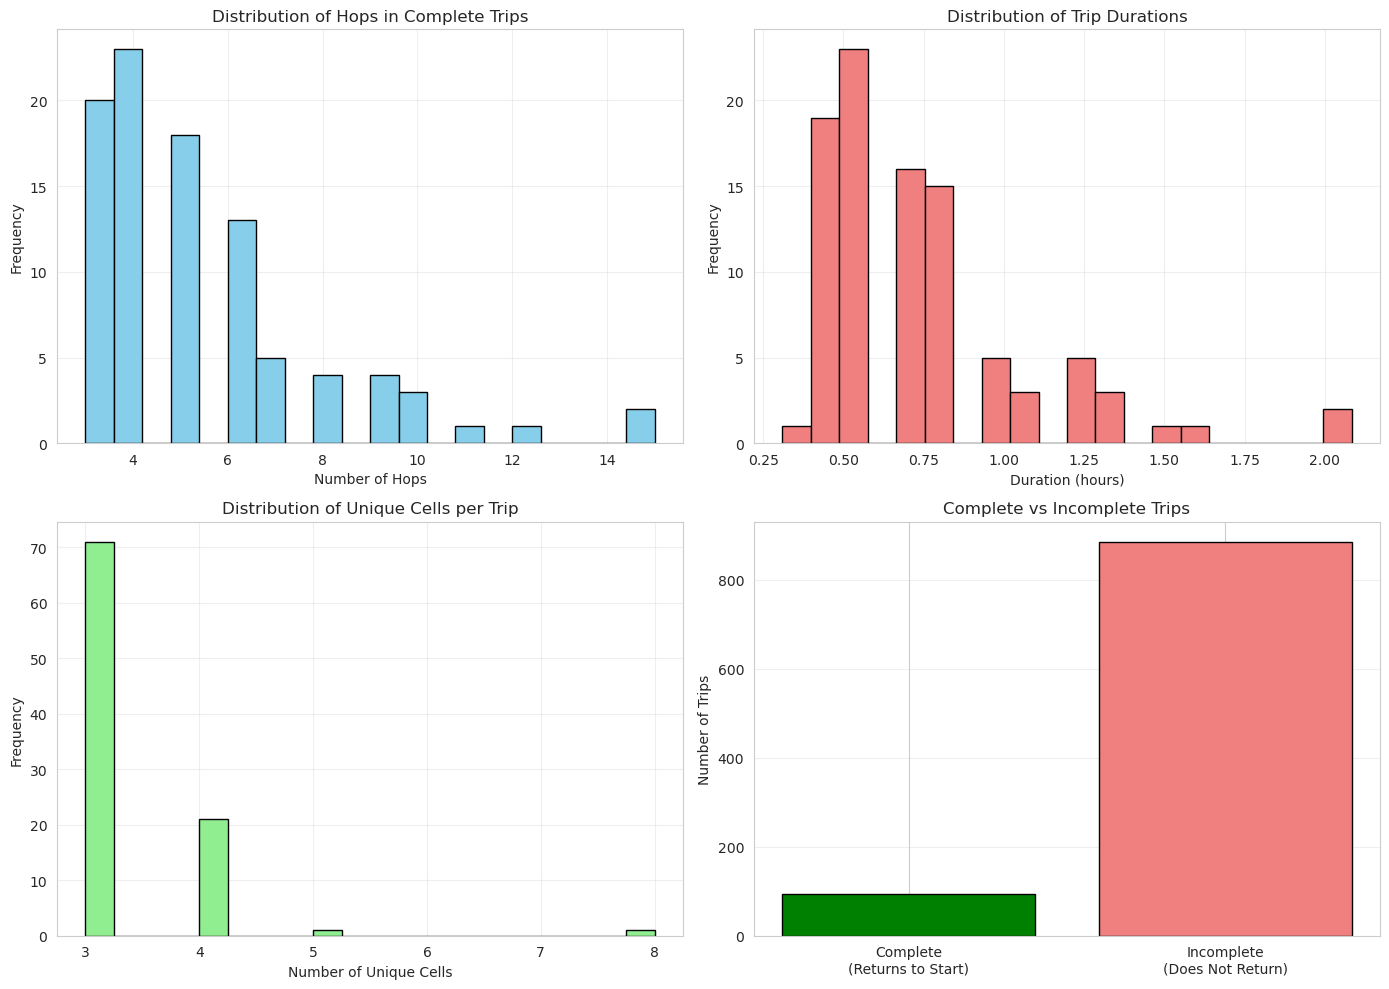

Trip statistics visualized


In [35]:
### 6.1 Trip Statistics Visualization

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution of hops
hop_counts = [trip.get_hop_count() for trip in complete_trips]
axes[0, 0].hist(hop_counts, bins=20, color='skyblue', edgecolor='black')
axes[0, 0].set_xlabel('Number of Hops')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Hops in Complete Trips')
axes[0, 0].grid(alpha=0.3)

# Distribution of trip duration
durations = [trip.get_trip_duration().total_seconds() / 3600 for trip in complete_trips]
axes[0, 1].hist(durations, bins=20, color='lightcoral', edgecolor='black')
axes[0, 1].set_xlabel('Duration (hours)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Trip Durations')
axes[0, 1].grid(alpha=0.3)

# Unique cells per trip
unique_cells = [len(trip.get_unique_cells()) for trip in complete_trips]
axes[1, 0].hist(unique_cells, bins=20, color='lightgreen', edgecolor='black')
axes[1, 0].set_xlabel('Number of Unique Cells')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Unique Cells per Trip')
axes[1, 0].grid(alpha=0.3)

# Complete vs Incomplete trips
trip_types = ['Complete\n(Returns to Start)', 'Incomplete\n(Does Not Return)']
trip_counts = [stats['complete_trips'], 
               stats['total_trips'] - stats['complete_trips']]
colors = ['green', 'lightcoral']
axes[1, 1].bar(trip_types, trip_counts, color=colors, edgecolor='black')
axes[1, 1].set_ylabel('Number of Trips')
axes[1, 1].set_title('Complete vs Incomplete Trips')
axes[1, 1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Trip statistics visualized")

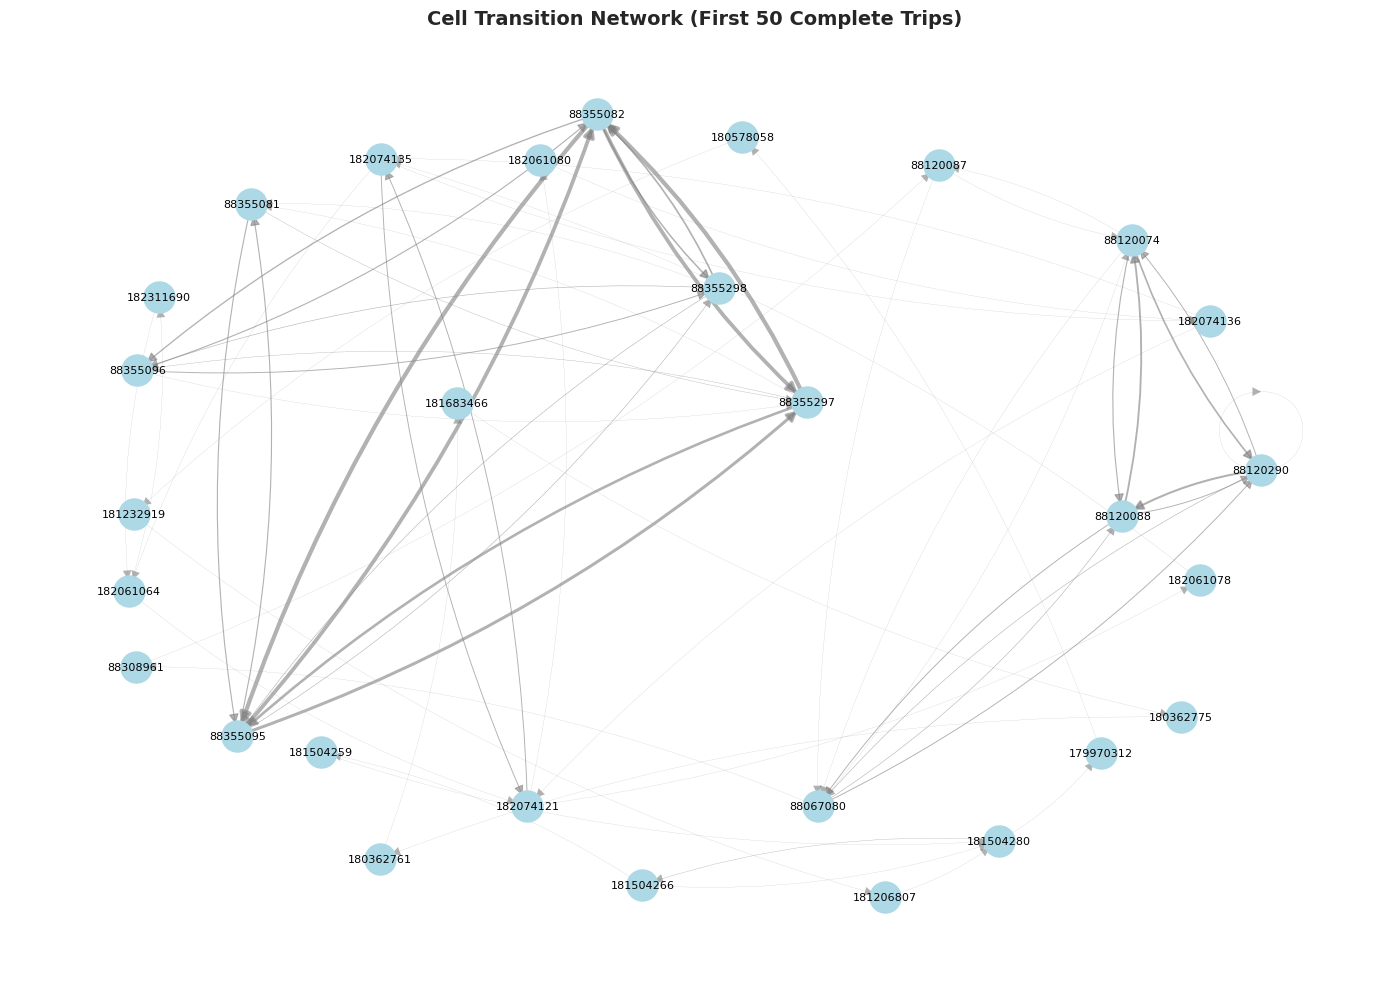

Network visualization created with 29 nodes and 64 edges


In [36]:
### 6.2 Network Graph of Cell Transitions

# Build transition graph from complete trips
transition_graph = nx.DiGraph()
edge_weights = defaultdict(int)

for trip in complete_trips[:50]:  # Use first 50 for clarity
    cells = trip.visited_cells
    for i in range(len(cells) - 1):
        from_cell = cells[i]
        to_cell = cells[i + 1]
        transition_graph.add_edge(from_cell, to_cell)
        edge_weights[(from_cell, to_cell)] += 1

# Create visualization
fig, ax = plt.subplots(figsize=(14, 10))

# Use spring layout for better visualization
pos = nx.spring_layout(transition_graph, k=2, iterations=50, seed=42)

# Draw nodes
nx.draw_networkx_nodes(transition_graph, pos, node_color='lightblue', 
                       node_size=500, ax=ax)

# Draw edges with width proportional to weight
edges = transition_graph.edges()
weights = [edge_weights[edge] for edge in edges]
max_weight = max(weights) if weights else 1
widths = [3 * w / max_weight for w in weights]

nx.draw_networkx_edges(transition_graph, pos, width=widths, 
                       edge_color='gray', alpha=0.6, ax=ax,
                       arrowsize=15, arrowstyle='-|>', connectionstyle='arc3,rad=0.1')

# Draw labels
nx.draw_networkx_labels(transition_graph, pos, font_size=8, ax=ax)

ax.set_title('Cell Transition Network (First 50 Complete Trips)', fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

print(f"Network visualization created with {transition_graph.number_of_nodes()} nodes "
      f"and {transition_graph.number_of_edges()} edges")

## 7. Practical Examples with Real Data

Apply the trip detection algorithm to demonstrate various use cases and edge cases.

In [37]:
### 7.1 Use Case: Identify Most Common Circular Routes

# Find the most common complete trip paths
path_counts = defaultdict(int)
for trip in complete_trips:
    path = trip.get_path()
    path_counts[path] += 1

# Sort by frequency
top_routes = sorted(path_counts.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top 10 Most Common Circular Routes:")
print("-" * 80)
for i, (path, count) in enumerate(top_routes, 1):
    print(f"{i:2d}. Count: {count:3d} | Path: {path}")
print()

Top 10 Most Common Circular Routes:
--------------------------------------------------------------------------------
 1. Count:   2 | Path: 182038281 -> 182204183 -> 182038281 -> 182038295 -> 182038281
 2. Count:   1 | Path: 88355082 -> 88355297 -> 88355082 -> 88355095 -> 88355082 -> 88355297 -> 88355096 -> 88355082
 3. Count:   1 | Path: 88355297 -> 88355095 -> 88355082 -> 88355297 -> 88355082 -> 88355297 -> 88355082 -> 88355297 -> 88355082 -> 88355095 -> 88355297
 4. Count:   1 | Path: 88355297 -> 88355095 -> 88355082 -> 88355095 -> 88355297 -> 88355082 -> 88355095 -> 88355082 -> 88355297
 5. Count:   1 | Path: 88355082 -> 88355297 -> 88355082 -> 88355095 -> 88355082
 6. Count:   1 | Path: 88355082 -> 88355095 -> 88355082 -> 88355297 -> 88355095 -> 88355297 -> 88355095 -> 88355297 -> 88355082 -> 88355297 -> 88355082
 7. Count:   1 | Path: 88355082 -> 88355096 -> 88355297 -> 88355082
 8. Count:   1 | Path: 88355096 -> 88355298 -> 88355082 -> 88355096
 9. Count:   1 | Path: 88355298 ->

In [38]:
### 7.2 Use Case: User Trip Behavior Analysis

# Analyze per-user statistics
user_trip_stats = defaultdict(lambda: {'total': 0, 'complete': 0, 'hops': []})

for trip in all_trips:
    user = trip.user_id
    user_trip_stats[user]['total'] += 1
    if trip.is_complete_trip():
        user_trip_stats[user]['complete'] += 1
        user_trip_stats[user]['hops'].append(trip.get_hop_count())

# Create summary dataframe
user_summary = []
for user, stats in user_trip_stats.items():
    complete_trips_user = stats['complete']
    total_trips_user = stats['total']
    complete_pct = (complete_trips_user / total_trips_user * 100) if total_trips_user > 0 else 0
    avg_hops = np.mean(stats['hops']) if stats['hops'] else 0
    
    user_summary.append({
        'User': user,
        'Total Trips': total_trips_user,
        'Complete Trips': complete_trips_user,
        'Complete %': complete_pct,
        'Avg Hops': avg_hops
    })

user_summary_df = pd.DataFrame(user_summary).sort_values('Complete %', ascending=False)
print("User Trip Behavior Analysis:")
print(user_summary_df.to_string(index=False))
print()

User Trip Behavior Analysis:
                            User  Total Trips  Complete Trips  Complete %  Avg Hops
94E8C7E66178728D5715DFE6AAD89700          149              33   22.147651  5.727273
16621DDA5F0E80D3B3045F101C0F59DB          178              31   17.415730  5.709677
936A3165571EADFB9C6D27ADEF6EBB4F           25               4   16.000000  5.250000
EC5CAE0D1924BAC7CBD88D03DA185597           72              10   13.888889  4.800000
E7C78BF447DEDE56A3C9A8CD30B94B96           65               5    7.692308  4.800000
BE5189916CDBF78E258FCFF6D344D02A           32               2    6.250000  4.000000
6164D632D2898E5E05BCE05794472C77           33               2    6.060606  5.000000
E2688BA0F4A1F50C693FF16A2ACFCDE7           33               2    6.060606  3.500000
BE5189916CDBF78E98282E4BDE24E7B4           24               1    4.166667  8.000000
F140A413CDBACB245F79DAE1D7438EC4           24               1    4.166667  3.000000
E2688BA0F4A1F50C0E03455B664A6D93           25  

In [39]:
### 7.3 Use Case: Detect Unusually Long Circular Trips

# Identify trips with unusual characteristics
hop_counts = [trip.get_hop_count() for trip in complete_trips]
q75 = np.percentile(hop_counts, 75)
q25 = np.percentile(hop_counts, 25)
iqr = q75 - q25
upper_bound = q75 + 1.5 * iqr

unusual_trips = [trip for trip in complete_trips 
                 if trip.get_hop_count() > upper_bound]

print(f"Detecting Unusually Long Trips (>75th percentile + 1.5*IQR)")
print(f"Threshold: {upper_bound:.0f} hops")
print(f"Found {len(unusual_trips)} unusual trips:\n")

for i, trip in enumerate(unusual_trips[:5], 1):
    print(f"{i}. User: {trip.user_id}")
    print(f"   Trip ID: {trip.trip_id}")
    print(f"   Hops: {trip.get_hop_count()}")
    print(f"   Unique cells: {len(trip.get_unique_cells())}")
    print(f"   Duration: {trip.get_trip_duration()}\n")

Detecting Unusually Long Trips (>75th percentile + 1.5*IQR)
Threshold: 9 hops
Found 7 unusual trips:

1. User: 16621DDA5F0E80D3B3045F101C0F59DB
   Trip ID: 16621DDA5F0E80D3B3045F101C0F59DB_69
   Hops: 10
   Unique cells: 3
   Duration: 0 days 01:20:48

2. User: 16621DDA5F0E80D3B3045F101C0F59DB
   Trip ID: 16621DDA5F0E80D3B3045F101C0F59DB_76
   Hops: 10
   Unique cells: 3
   Duration: 0 days 01:20:48

3. User: 16621DDA5F0E80D3B3045F101C0F59DB
   Trip ID: 16621DDA5F0E80D3B3045F101C0F59DB_176
   Hops: 15
   Unique cells: 3
   Duration: 0 days 02:01:10.038000

4. User: 16621DDA5F0E80D3B3045F101C0F59DB
   Trip ID: 16621DDA5F0E80D3B3045F101C0F59DB_219
   Hops: 10
   Unique cells: 3
   Duration: 0 days 01:20:42

5. User: 94E8C7E66178728D5715DFE6AAD89700
   Trip ID: 94E8C7E66178728D5715DFE6AAD89700_443
   Hops: 11
   Unique cells: 3
   Duration: 0 days 01:28:56.412000



## 8. Summary and Conclusions

This notebook demonstrates a comprehensive approach to detecting and analyzing circular trips in movement data. The methodology can be applied to:

- **Telecommunication Networks**: Analyzing user movement patterns through cell towers
- **Transportation Systems**: Tracking vehicles that return to origin points
- **Retail Analytics**: Understanding customer movement patterns in stores
- **Urban Planning**: Analyzing pedestrian traffic flows

### Key Takeaways:

1. **Trip Detection**: Successfully identified trips using session timeout criteria
2. **Circular Trip Filtering**: Distinguished between complete (return to start) and incomplete trips
3. **Statistical Analysis**: Computed meaningful metrics like hop counts and trip duration
4. **Visualization**: Used network graphs and histograms to reveal movement patterns
5. **Practical Applications**: Demonstrated user behavior analysis and anomaly detection

# Close DuckDB connection
if 'con' in locals():
    con.close()
    print("DuckDB connection closed")
    
### Next Steps:

- Integrate with real-world data sources (databases, APIs)
- Add machine learning models for pattern prediction
- Implement alert systems for unusual trip patterns
- Scale the algorithm for production environments